In [118]:
import pandas as pd
import numpy as np
import pymc as pm
import scipy.stats as stats
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

## Get player details


In [119]:
players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
# players_preds = players_preds.dropna(axis=1).copy()
players_preds = players_preds.drop(['event', 'understat_name', 'fpl_name', 'team', 'xG_preds', 'xA_preds', 'cs_preds', 'y_preds', 'saves_preds', 'xgc_preds', 'h_team', 'a_team','was_home'], axis=1)
player_cols = players_preds.columns.tolist()


In [120]:
gw=35
data_22_23 = pd.read_csv('../FPL predictors/with new features/data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('../FPL predictors/with new features/data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('../FPL predictors/with new features/data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

data_cols = player_cols.copy()
data_cols.pop(data_cols.index('xP_preds'))
data_cols.pop(data_cols.index('player_team'))


data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][data_cols]
def_data = data[data['position'] == 'DEF'][data_cols]
mid_data = data[data['position'] == 'MID'][data_cols]
fwd_data = data[data['position'] == 'FWD'][data_cols]

gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.dropna()
gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.dropna()
def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

mid_data = mid_data.select_dtypes(include=[np.number])
mid_data = mid_data.dropna()
mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

fwd_data = fwd_data.select_dtypes(include=[np.number])
fwd_data = fwd_data.dropna()
fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

In [121]:

X_def = def_data  # shape: (n_defenders, n_features)

# 1. Standardize (PCA works best on standardized data)
scaler_gk = StandardScaler(with_mean=True, with_std=True)
scaler_def = StandardScaler(with_mean=True, with_std=True)
scaler_mid = StandardScaler(with_mean=True, with_std=True)
scaler_fwd = StandardScaler(with_mean=True, with_std=True)

X_gk = scaler_gk.fit_transform(gk_data)
X_def = scaler_def.fit_transform(def_data)
X_mid = scaler_mid.fit_transform(mid_data)
X_fwd = scaler_fwd.fit_transform(fwd_data)


# 2. Choose # of components or variance threshold
pca_gk = PCA(n_components=0.95)  # 0.95 = keep enough PCs to explain 95% of variance
pca_def = PCA(n_components=0.95)
pca_mid = PCA(n_components=0.95)
pca_fwd = PCA(n_components=0.95)

# 3. Fit PCA and transform
X_gk_pca = pd.DataFrame(pca_gk.fit_transform(X_gk))
X_def_pca = pd.DataFrame(pca_def.fit_transform(X_def))
X_mid_pca = pd.DataFrame(pca_mid.fit_transform(X_mid))
X_fwd_pca = pd.DataFrame(pca_fwd.fit_transform(X_fwd))

print("Original shape:", X_gk.shape, X_def.shape, X_mid.shape, X_fwd.shape)
print("Reduced shape:", X_gk_pca.shape, X_def_pca.shape, X_mid_pca.shape, X_fwd_pca.shape)

# # 4. Check variance explained
# print("Explained variance ratio per PC:", pca_gk.explained_variance_ratio_)
# print("Cumulative explained variance:", np.cumsum(pca_gk.explained_variance_ratio_))


Original shape: (501, 236) (2387, 236) (3823, 236) (863, 236)
Reduced shape: (501, 65) (2387, 69) (3823, 69) (863, 65)


In [122]:

data_ = players_preds[data_cols]
gk_data_tar = players_preds[players_preds['position'] == 'GK'][gk_data.columns]
def_data_tar = players_preds[players_preds['position'] == 'DEF'][def_data.columns]
mid_data_tar = players_preds[players_preds['position'] == 'MID'][mid_data.columns]
fwd_data_tar = players_preds[players_preds['position'] == 'FWD'][fwd_data.columns]


gk_data_tar = gk_data_tar.select_dtypes(include=[np.number])
gk_data_tar = pd.DataFrame(minmax_scale(gk_data_tar), columns=gk_data_tar.columns, index=gk_data_tar.index)

def_data_tar = def_data_tar.select_dtypes(include=[np.number])
# Data
def_data_tar = pd.DataFrame(minmax_scale(def_data_tar), columns=def_data_tar.columns, index=def_data_tar.index)

mid_data_tar = mid_data_tar.select_dtypes(include=[np.number])
mid_data_tar = pd.DataFrame(minmax_scale(mid_data_tar), columns=mid_data_tar.columns, index=mid_data_tar.index)

fwd_data_tar = fwd_data_tar.select_dtypes(include=[np.number])
fwd_data_tar = pd.DataFrame(minmax_scale(fwd_data_tar), columns=fwd_data_tar.columns, index=fwd_data_tar.index)

# Make sure there are no nan or inf
def clean_array(arr):
    arr = np.nan_to_num(arr, nan=0.0, posinf=1e6, neginf=-1e6)
    return arr

gk_data_tar  = clean_array(gk_data_tar)
def_data_tar = clean_array(def_data_tar)
mid_data_tar = clean_array(mid_data_tar)
fwd_data_tar = clean_array(fwd_data_tar)


## Wo Component


In [123]:
def get_beta(data):
    # Ensure data is numeric
    data = data.select_dtypes(include=[np.number])  # Drop non-numeric columns

    # Shape parameters
    np.random.seed(42)
    num_players, num_features = data.shape

    print(f"Number of Players: {num_players}, Features: {num_features}")

    # Convert to NumPy with float type
    X = data.to_numpy(dtype=np.float64)
    X = X.reshape((num_players, num_features))
    print(X.shape)

    # Observed probability distribution (Ensure valid probabilities)
    p = np.abs(np.random.randn(num_players, ))
    p /= p.sum( keepdims=True)  # Normalize to sum to 1
    print("p shape:", p.shape)

    with pm.Model() as model:
        # Prior: Uniform distribution for β
        beta = pm.Uniform("beta", lower=-1, upper=1, shape=(num_features,))
        print("Beta shape:", beta.shape)

        # Compute α = exp(X β) and ensure correct shape
        epsilon = 1e-3
        alpha = pm.math.exp(pm.math.dot(X, beta)) + epsilon
        print("Alpha shape:", alpha.shape)

        # Dirichlet likelihood (Ensure shape matches p)
        p = pm.Dirichlet("p", a=alpha, observed=p)
        # Debugging step to check the model
        model.debug(verbose=True)
        # MCMC Sampling
        trace = pm.sample(2000, return_inferencedata=True, target_accept=0.9)

    # Get estimated β values
    beta_estimated = trace.posterior["beta"].mean(dim=["chain", "draw"])
    print("Estimated β values:", beta_estimated.values)
    return beta_estimated

### Get betas


In [124]:
def simulate_observed_probs(X: pd.DataFrame):
    X = X.fillna(0)
    np.random.seed(42)
    num_features = X.shape[1]
    true_beta = np.random.uniform(-0.5, 0.5, size=(num_features,))
    logits = X @ true_beta
    probs = np.exp(logits)
    probs /= probs.sum()
    return probs

simulate_observed_probs(gk_data)

23       0.001270
24       0.000815
25       0.001514
26       0.001125
27       0.004494
           ...   
11071    0.000870
11072    0.000464
11073    0.001270
11074    0.001883
11075    0.001015
Length: 501, dtype: float64

In [125]:
def dirichlet_regression_beta_auto(data: pd.DataFrame):
    """
    Perform Bayesian Dirichlet Regression.
    If no observed_probs are given, simulate them based on features.
    """
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Data must be a pandas DataFrame.")

    if data.isnull().any().any():
        raise ValueError("Data contains NaN values. Please clean it first.")

    num_players, num_features = data.shape
    print(f"Number of Players: {num_players}, Number of Features: {num_features}")

    X = data.to_numpy(dtype=np.float64)
    # X = X.fillna(0)

    # --- Simulate observed probabilities ---
    observed_probs = simulate_observed_probs(data)

    with pm.Model() as model:
        # Wide normal prior
        beta = pm.Normal("beta", mu=0, sigma=10, shape=(num_features,))

        eta = pm.math.dot(X, beta)
        alpha = pm.math.exp(eta)

        pm.Dirichlet("obs", a=alpha, observed=observed_probs)

        trace = pm.sample(
            draws=1000,
            tune=50,
            target_accept=0.95,
            chains=2,
            cores=2,
            return_inferencedata=True,
            progressbar=True,
            # nuts_sampler="numpyro"
        )

    beta_estimated = trace.posterior["beta"].mean(dim=["chain", "draw"]).values

    print("Estimated β values:\n", beta_estimated)
    return beta_estimated

In [126]:
# Suppose your player data
X_data_gk = X_gk_pca.copy()
# X_data_gk = X_data_gk.fillna(0)
# Now fit!
beta_gk = dirichlet_regression_beta_auto(X_data_gk)
# eta_gk = get_beta(gk_data)

Number of Players: 501, Number of Features: 65


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 45 seconds.
There were 939 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [ 0.10126161  0.29933606 -0.56749633  0.53557032  0.21033153 -0.2767602
 -0.30095182 -0.25917652  0.40575511 -0.68010732  0.00226138  0.18522359
  0.48782948  0.29625371  0.42940061  0.0512685  -0.03364646  0.12524932
  0.30468213  0.18326727 -0.02519585 -0.46718937  0.05647042 -0.00863528
 -0.24476893  0.05285573  0.44071351  0.1600245   0.34751329 -0.26248788
  0.2280509  -0.21963915 -0.28325124  0.15715607 -0.2120133   0.01724822
 -0.46259317  0.74369149 -0.33534854 -0.31470444  0.27024909  0.0972462
 -0.65706331 -0.48520183  0.13065955  0.0917364  -0.1049991   0.35216722
 -0.07237984 -0.17928302  0.4839881   0.37927069  0.44228039  0.29485254
 -0.47027269 -0.64090294 -0.27406336  0.11136055  0.12138718  0.33932929
 -0.13982242 -0.55835132  0.2313807   0.04900676  0.27112208]


In [127]:
# Suppose your player data
X_data_def = X_def_pca.copy()

# Now fit!
beta_def = dirichlet_regression_beta_auto(X_data_def)

Number of Players: 2387, Number of Features: 69


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 62 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [ 3.27676085e-03  2.35008050e-01 -4.53339313e-01 -2.84285561e-01
 -7.47146739e-02  2.92489089e-01  3.17102079e-01  2.34702322e-01
 -3.16640992e-01  2.20959099e-01 -1.48697023e-01 -6.63290506e-02
 -1.92646317e-01  3.23859648e-01  1.66156790e-01  5.32251326e-02
  3.26687177e-01 -2.98663758e-01 -5.68625560e-01 -9.49481292e-05
  5.76705329e-02 -7.81100595e-02 -4.61298187e-01 -2.30400740e-01
  2.09627032e-01  3.76213591e-01  7.26929010e-02  3.35931507e-01
  1.20458742e-02 -1.73823127e-01  5.23670633e-02  1.87401151e-01
  2.28849043e-01 -7.54082085e-01 -1.98450335e-01  4.40867628e-01
 -6.04050703e-01  5.45528061e-01 -3.98231003e-01 -2.26187125e-01
  6.46991221e-01 -2.38156892e-01  8.29590061e-01 -8.75910271e-02
 -5.36559019e-01  5.39762074e-01 -3.73811396e-01  1.56285432e-01
 -2.56518137e-01  5.21797007e-01  6.64154196e-01  2.84082903e-01
  4.49802781e-01 -2.14935397e-01 -3.04969565e-01 -4.87987538e-01
 -5.39080540e-01  3.26106875e-01 -2.34838621e-01 -4.63487773e-01
 -1.

In [128]:
# Suppose your player data
X_data_mid = X_mid_pca.copy()

# Now fit!
beta_mid = dirichlet_regression_beta_auto(X_data_mid)

Number of Players: 3823, Number of Features: 69


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 208 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [-0.29667317  0.07139985 -0.06655061  0.08561822  0.3192384   0.26479388
 -0.28950385  0.16321462 -0.03994292 -0.12689161 -0.33189384 -0.50242328
  0.03070342 -0.50354807 -0.59425885  0.15256243  0.02092094  0.25286353
 -0.45783682 -0.47009245 -0.37740121  0.09846137  0.03615287  0.18075286
  0.06068781 -0.0715735   0.16835848  0.66751158  0.46066129  0.12167743
 -0.09815075  0.23076054  0.65988427 -0.34632753 -0.55717769 -0.13422948
  0.15515818 -0.04535308 -0.30663664  0.69341918  0.12700807  0.00251128
 -0.02019854 -0.22768172  0.53347043 -0.02096965 -0.05119794  0.21640734
  0.14761018  0.3305808  -0.350745    0.14259112  0.02608022 -0.32787863
  0.30055327 -0.05497374 -0.28092843 -0.47212907 -0.48005745  0.18408836
  0.32868078 -0.59072125  0.72011456  0.13194279 -0.39462864 -0.06374508
 -0.36280821  0.05422595 -0.49582909]


In [129]:
# Suppose your player data
X_data_fwd = X_fwd_pca.copy()
X_data_fwd = X_data_fwd.fillna(0)

# Now fit!
beta_fwd = dirichlet_regression_beta_auto(X_data_fwd)


Number of Players: 863, Number of Features: 65


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 701 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [ 0.08340438  0.36315527  0.10347713  0.19190869 -0.09502729  0.12082996
 -0.01402131  0.50479252  0.36420145  0.34274853 -0.39510109 -0.08135851
  0.44481745 -0.55106443 -0.23459258 -0.33652358 -0.23045969  0.1659965
 -0.50393626  0.14256609 -0.31715004 -0.38560647  0.18528175 -0.16153913
  0.08405285  0.40201211  0.16096866 -0.09503436 -0.25893638  0.03919087
  0.38742531 -0.39157956  0.01129806 -0.02724313 -0.13323254 -0.17016161
 -0.03042307 -0.52674772  0.42161094 -0.06756042 -0.16221412 -0.40599785
 -0.05441608  0.14404659 -0.44019914 -0.16659099 -0.09827973  0.33717521
 -0.21989366  0.27290544  0.0649603   0.43808613  0.43984465  0.20742214
 -0.1977465  -0.15652914  0.06742526 -0.28344544 -0.48243186  0.20750293
 -0.02452522  0.4090711  -0.36343138 -0.02724678  0.09913503]


In [130]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_gk
}).to_csv('./gk_beta.csv', index=False)

pd.DataFrame({
    "def": beta_def
}).to_csv('./def_beta.csv', index=False)

pd.DataFrame({
    "mid": beta_mid
}).to_csv('./mid_beta.csv', index=False)

pd.DataFrame({
    "fwd": beta_fwd
}).to_csv('./fwd_beta.csv', index=False)

### Use the betas


In [131]:

# data_ = data_tar[data_cols]
# gk_data_tar = data_tar[data_tar['position'] == '1'][gk_data.columns]
# def_data_tar = data_tar[data_tar['position'] == '2'][def_data.columns]
# mid_data_tar = data_tar[data_tar['position'] == '3'][mid_data.columns]
# fwd_data_tar = data_tar[data_tar['position'] == '4'][fwd_data.columns]


# # gk_data_tar = gk_data_tar.select_dtypes(include=[np.number])
# # gk_data_tar = gk_data_tar.drop(['expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_3', 'goals_scored_3', 'own_goals_3', 'goals_3', 'shots_3', 'xG_3',
# #                         'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xA_3', 'assists_y_3', 'expected_goals_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_5', 'goals_scored_5', 'own_goals_5', 'goals_5', 'shots_5', 'xG_5',
# #                         'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xA_5', 'assists_y_5'], axis=1)
# gk_data_tar = pd.DataFrame(minmax_scale(gk_data_tar), columns=gk_data_tar.columns, index=gk_data_tar.index)

# def_data_tar = def_data_tar.select_dtypes(include=[np.number])
# # def_data_tar = def_data_tar.drop(['expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_3', 'goals_scored_3', 'own_goals_3', 'goals_3', 'shots_3', 'xG_3',
# #                         'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xA_3', 'assists_y_3', 'expected_goals_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_5', 'goals_scored_5', 'own_goals_5', 'goals_5', 'shots_5', 'xG_5',
# #                         'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xA_5', 'assists_y_5','whh','whd', 'wha'], axis=1)
# def_data_tar = pd.DataFrame(minmax_scale(def_data_tar), columns=def_data_tar.columns, index=def_data_tar.index)

# mid_data_tar = mid_data_tar.select_dtypes(include=[np.number])
# # mid_data_tar = mid_data_tar.drop(['expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_3', 'goals_scored_3', 'own_goals_3', 'goals_3', 'shots_3', 'xG_3',
# #                         'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xA_3', 'assists_y_3', 'expected_goals_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_5', 'goals_scored_5', 'own_goals_5', 'goals_5', 'shots_5', 'xG_5',
# #                         'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xA_5', 'assists_y_5','whh','whd', 'wha'], axis=1)
# mid_data_tar = pd.DataFrame(minmax_scale(mid_data_tar), columns=mid_data_tar.columns, index=mid_data_tar.index)

# fwd_data_tar = fwd_data_tar.select_dtypes(include=[np.number])
# fwd_data_tar = pd.DataFrame(minmax_scale(fwd_data_tar), columns=fwd_data_tar.columns, index=fwd_data_tar.index)


In [132]:
beta_gk_ = pd.read_csv('./gk_beta.csv').values.squeeze()
beta_def_ = pd.read_csv('./def_beta.csv').values.squeeze()
beta_mid_ = pd.read_csv('./mid_beta.csv').values.squeeze()
beta_fwd_ = pd.read_csv('./fwd_beta.csv').values.squeeze()

alpha_gk_pred = np.exp(np.dot(gk_data_tar, beta_gk_.T))
alpha_def_pred = np.exp(np.dot(def_data_tar, beta_def_.T))
alpha_mid_pred = np.exp(np.dot(mid_data_tar, beta_mid_.T))
alpha_fwd_pred = np.exp(np.dot(fwd_data_tar, beta_fwd_.T))

ValueError: shapes (17,236) and (65,) not aligned: 236 (dim 1) != 65 (dim 0)

In [ ]:
dir_gk = np.random.dirichlet(alpha_gk_pred).tolist()
dir_def = np.random.dirichlet(alpha_def_pred).tolist()
dir_mid = np.random.dirichlet(alpha_mid_pred).tolist()
dir_fwd = np.random.dirichlet(alpha_fwd_pred).tolist()

In [ ]:
dir_ = tuple([dir_gk, dir_def, dir_mid, dir_fwd])

In [ ]:
f = len(beta_gk_)  # Number of group

# Step 2: Define and sample from Dirichlet distribution
with pm.Model() as model:
    p_gk = pm.Dirichlet("p_gk", a=alpha_gk_pred)  # Ensure correct shape
    p_def = pm.Dirichlet("p_def", a=alpha_def_pred)  # Ensure correct shape
    p_mid = pm.Dirichlet("p_mid", a=alpha_mid_pred)  # Ensure correct shape
    p_fwd = pm.Dirichlet("p_fwd", a=alpha_fwd_pred)  # Ensure correct shape

    trace = pm.sample_prior_predictive(samples=1)

Sampling: [p_def, p_fwd, p_gk, p_mid]


In [ ]:
# Extract samples correctly
sampled_p_gk = trace.prior["p_gk"].values.squeeze()  # Ensure shape is (f, num_features)
sampled_p_def = trace.prior["p_def"].values.squeeze()  # Ensure shape is (f, num_features)
sampled_p_mid = trace.prior["p_mid"].values.squeeze()  # Ensure shape is (f, num_features)
sampled_p_fwd = trace.prior["p_fwd"].values.squeeze()  # Ensure shape is (f, num_features)"


In [ ]:
W = set()  # Placeholder for valid portfolios
Wo = []  # List to store accepted portfolios

In [ ]:
# Ensure sampled probabilities are valid
sampled_p_gk = np.nan_to_num(sampled_p_gk, nan=1.0 / len(sampled_p_gk))
sampled_p_def = np.nan_to_num(sampled_p_def, nan=1.0 / len(sampled_p_def))
sampled_p_mid = np.nan_to_num(sampled_p_mid, nan=1.0 / len(sampled_p_mid))
sampled_p_fwd = np.nan_to_num(sampled_p_fwd, nan=1.0 / len(sampled_p_fwd))

# Normalize probabilities to ensure they sum to 1
sampled_p_gk /= sampled_p_gk.sum()
sampled_p_def /= sampled_p_def.sum()
sampled_p_mid /= sampled_p_mid.sum()
sampled_p_fwd /= sampled_p_fwd.sum()

# Generate random samples
gk = np.random.multinomial(1, sampled_p_gk)
def_ = np.random.multinomial(3, sampled_p_def)
mid = np.random.multinomial(4, sampled_p_mid)
fwd = np.random.multinomial(4, sampled_p_fwd)

# Extract indices of selected players
gk_idx = [i for i, x in enumerate(gk) if x == 1]
def_idx = [i for i, x in enumerate(def_) if x == 1]
mid_idx = [i for i, x in enumerate(mid) if x == 1]
fwd_idx = [i for i, x in enumerate(fwd) if x == 1]

gk_idx, def_idx, mid_idx, fwd_idx

([16], [73], [61, 84, 86, 126], [0, 7])

In [ ]:
# Manually compute alpha values and check ranges
epsilon = 1e-3
alpha_g = np.exp(np.dot(gk_data_tar, beta_gk_.T)) + epsilon
alpha_d = np.exp(np.dot(def_data_tar, beta_def_.T)) + epsilon
alpha_m = np.exp(np.dot(mid_data_tar, beta_mid_.T)) + epsilon
alpha_f = np.exp(np.dot(fwd_data_tar, beta_fwd_.T)) + epsilon

print("Alpha gk: min", alpha_g.min(), " max", alpha_g.max())
print("Alpha def: min", alpha_d.min(), " max", alpha_d.max())
print("Alpha mid: min", alpha_m.min(), " max", alpha_m.max())
print("Alpha fwd: min", alpha_f.min(), " max", alpha_f.max())


Alpha gk: min 5484.645262794846  max 2195007.0641828105
Alpha def: min 2.4266797691860877  max 866.2095203238083
Alpha mid: min 4.778181386061589  max 1898.8787366506217
Alpha fwd: min 900.0371025557146  max 53785.181357295136


In [ ]:
# === Step 1: Define Constants ===
P = 100  # Total available players
C = 15  # Squad size
cin = 11  # Starting lineup size
budget = 100  # Maximum budget
Blb = 95  # Lower bound on spent budget
O = 1000  # Number of squad simulations

# Example positions: Assume these are valid players for selection
Pg, Pd, Pm, Pf = len(gk_data_tar), len(def_data_tar), len(mid_data_tar), len(fwd_data_tar)  # Players per position
positions = {"g": Pg, "d": Pd, "m": Pm, "f": Pf}

# === Step 2: Generate Dirichlet Parameters for Position Selection ===
with pm.Model():
    epsilon = 1e-3  # Small constant to avoid numerical issues
    alpha_g = np.exp(np.dot(gk_data_tar, beta_gk_.T)) + epsilon
    alpha_d = np.exp(np.dot(def_data_tar, beta_def_.T)) + epsilon
    alpha_m = np.exp(np.dot(mid_data_tar, beta_mid_.T)) + epsilon
    alpha_f = np.exp(np.dot(fwd_data_tar, beta_fwd_.T)) + epsilon

    pg = pm.Dirichlet("pg", a=alpha_g)  # Ensure correct shape
    pd_ = pm.Dirichlet("pd_", a=alpha_d)  # Ensure correct shape
    pmid = pm.Dirichlet("pm", a=alpha_m)  # Ensure correct shape
    pf = pm.Dirichlet("pf", a=alpha_f)  # Ensure correct shape

    trace = pm.sample(
            draws=1000,
            tune=500,
            target_accept=0.95,
            chains=4,
            cores=2,
            return_inferencedata=True,
            progressbar=True)

# Extract posterior means
pgk, pdef, pmid, pfwd = (
    trace.posterior["pg"].mean(dim=("chain", "draw")).values,
    trace.posterior["pd_"].mean(dim=("chain", "draw")).values,
    trace.posterior["pm"].mean(dim=("chain", "draw")).values,
    trace.posterior["pf"].mean(dim=("chain", "draw")).values,)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [pg, pd_, pm, pf]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 1262 seconds.


array([[<Axes: title={'center': 'pg'}>, <Axes: title={'center': 'pg'}>],
       [<Axes: title={'center': 'pd_'}>, <Axes: title={'center': 'pd_'}>],
       [<Axes: title={'center': 'pm'}>, <Axes: title={'center': 'pm'}>],
       [<Axes: title={'center': 'pf'}>, <Axes: title={'center': 'pf'}>]],
      dtype=object)

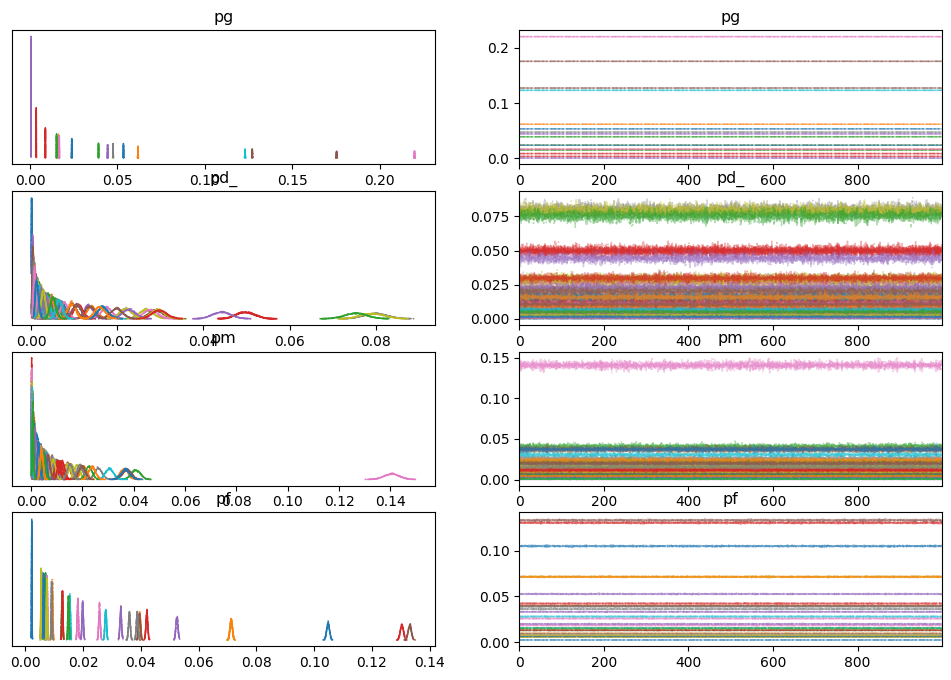

In [ ]:

az.plot_trace(data=trace, var_names=["pg", "pd_", 'pm', 'pf'])

In [ ]:
pg_ = pd.DataFrame({'gk': pgk})
pd_ = pd.DataFrame({'def': pdef})
pmid_ = pd.DataFrame({'mid': pmid})
pf_ = pd.DataFrame({'fwd': pfwd})

pg_.to_csv('./gk_beta_post.csv', index=False)
pd_.to_csv('./def_beta_post.csv', index=False)
pmid_.to_csv('./mid_beta_post.csv', index=False)
pf_.to_csv('./fwd_beta_post.csv', index=False)